Device: cuda:1
mel_idx: 4, meta_dim: 17
=== Baseline ===
Epoch 01 | train 58.4% | test 70.9% | sens 56.2% | auc 0.874
Epoch 02 | train 80.8% | test 74.2% | sens 70.2% | auc 0.892
Epoch 03 | train 86.7% | test 79.0% | sens 63.6% | auc 0.904
Epoch 04 | train 89.6% | test 79.0% | sens 62.0% | auc 0.905
Epoch 05 | train 92.1% | test 83.1% | sens 65.3% | auc 0.917
Epoch 06 | train 93.4% | test 82.0% | sens 60.3% | auc 0.918
Epoch 07 | train 94.8% | test 79.9% | sens 60.3% | auc 0.905
Epoch 08 | train 95.1% | test 79.2% | sens 66.1% | auc 0.909
Epoch 09 | train 95.7% | test 81.4% | sens 60.3% | auc 0.912
Epoch 10 | train 96.5% | test 78.4% | sens 74.4% | auc 0.907
Epoch 11 | train 96.5% | test 79.8% | sens 54.5% | auc 0.890
Epoch 12 | train 97.0% | test 81.8% | sens 62.8% | auc 0.915
Epoch 13 | train 97.3% | test 81.8% | sens 52.1% | auc 0.902
Epoch 14 | train 97.5% | test 79.8% | sens 71.1% | auc 0.911
Epoch 15 | train 97.7% | test 80.5% | sens 51.2% | auc 0.897
Epoch 16 | train 97.8% | tes

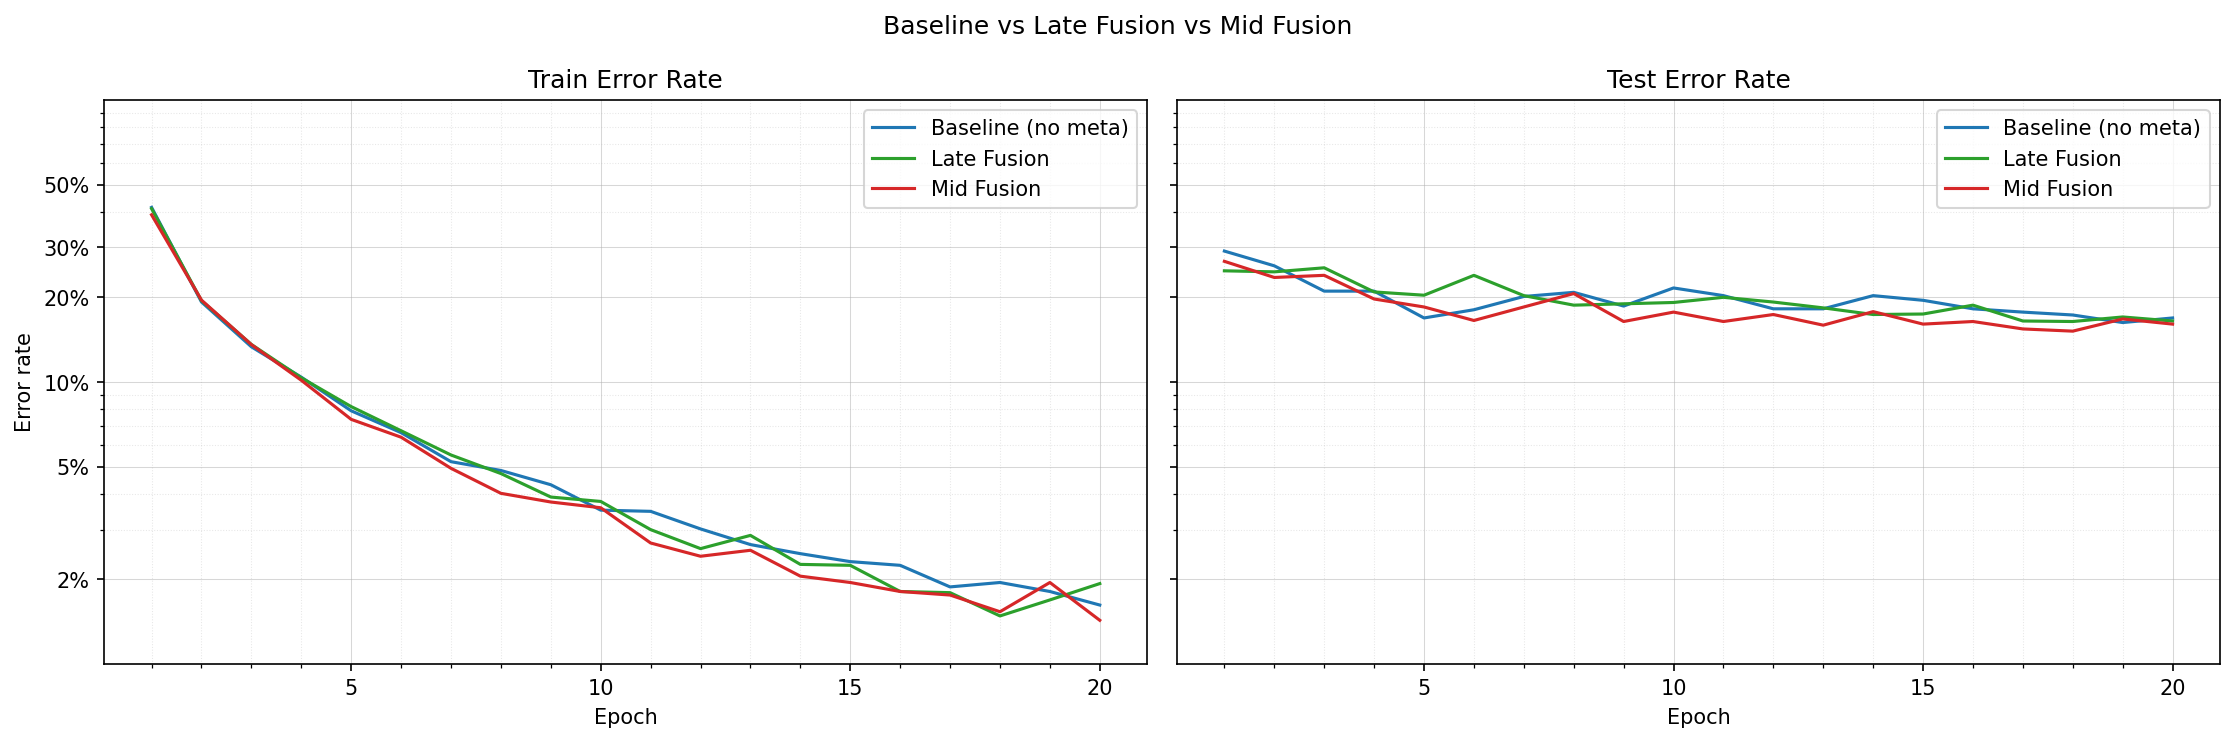

In [1]:
# ============================================================
# IMPORTS
# ============================================================
import sys
sys.path.append('../src')

import os
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights
from sklearn.model_selection import train_test_split
import pandas as pd

from dataset import HAM10000Dataset
from tools import train, test, score

device = torch.device("cuda:1")
print("Device:", device)

# ============================================================
# SPLIT + DATA
# ============================================================
df = pd.read_csv('../data/HAM10000_metadata_cleaned.csv')
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['dx']
)

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_dataset = HAM10000Dataset('../data/train.csv', '../data/HAM10000_images', transform=train_transform)
test_dataset  = HAM10000Dataset('../data/test.csv',  '../data/HAM10000_images', transform=test_transform)

mel_idx  = train_dataset.label_encoder.classes_.tolist().index('mel')
meta_dim = train_dataset.feature_dim
print(f"mel_idx: {mel_idx}, meta_dim: {meta_dim}")

def get_sampler():
    counts  = train_df['dx'].value_counts()
    weights = train_df['dx'].map(lambda x: 1.0 / counts[x]).values.copy()
    return WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

def initialize_loaders(batch_size=64, num_workers=8):
    sampler      = get_sampler()
    train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler,  num_workers=num_workers)
    test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False,    num_workers=num_workers)
    return train_loader, test_loader

# ============================================================
# MODEL A — Baseline (ResNet18, unfreeze=1, linear=2, no meta)
# ============================================================
class LensBaseline(nn.Module):
    def __init__(self, n_classes=7, dropout=0.5):
        super().__init__()
        self.resnet = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

        for param in self.resnet.parameters():
            param.requires_grad = False
        for param in self.resnet.layer4.parameters():
            param.requires_grad = True

        self.resnet.fc = nn.Identity()

        self.fc = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, n_classes)
        )
        for param in self.fc.parameters():
            param.requires_grad = True

    def forward(self, image, meta=None):
        return self.fc(self.resnet(image))

# ============================================================
# MODEL B — Late Fusion (concat meta po ResNecie)
# ============================================================
class LensLateFusion(nn.Module):
    def __init__(self, n_classes=7, dropout=0.5, meta_dim=17):
        super().__init__()
        self.resnet = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

        for param in self.resnet.parameters():
            param.requires_grad = False
        for param in self.resnet.layer4.parameters():
            param.requires_grad = True

        self.resnet.fc = nn.Identity()

        self.meta_mlp = nn.Sequential(
            nn.Linear(meta_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU()
        )

        self.fc = nn.Sequential(
            nn.Linear(512 + 32, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, n_classes)
        )
        for param in self.fc.parameters():
            param.requires_grad = True
        for param in self.meta_mlp.parameters():
            param.requires_grad = True

    def forward(self, image, meta):
        img_feat  = self.resnet(image)
        meta_feat = self.meta_mlp(meta)
        combined  = torch.cat([img_feat, meta_feat], dim=1)
        return self.fc(combined)

# ============================================================
# MODEL C — Mid Fusion (wstrzyknięcie przed layer4)
# ============================================================
class LensMidFusion(nn.Module):
    def __init__(self, n_classes=7, dropout=0.5, meta_dim=17):
        super().__init__()
        self.resnet = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

        for param in self.resnet.parameters():
            param.requires_grad = False
        for param in self.resnet.layer4.parameters():
            param.requires_grad = True

        # MLP metadanych → 256 żeby pasowało do inputu layer4
        self.meta_mlp = nn.Sequential(
            nn.Linear(meta_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 256),
            nn.ReLU()
        )

        # Projekcja 256+256 → 256 przed layer4
        self.fusion_proj = nn.Sequential(
            nn.Linear(256 + 256, 256),
            nn.ReLU()
        )

        self.avgpool = self.resnet.avgpool

        self.fc = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, n_classes)
        )

        for param in self.meta_mlp.parameters():
            param.requires_grad = True
        for param in self.fusion_proj.parameters():
            param.requires_grad = True
        for param in self.fc.parameters():
            param.requires_grad = True

    def forward(self, image, meta):
        x = self.resnet.conv1(image)
        x = self.resnet.bn1(x)
        x = self.resnet.relu(x)
        x = self.resnet.maxpool(x)
        x = self.resnet.layer1(x)
        x = self.resnet.layer2(x)
        x = self.resnet.layer3(x)  # [B, 256, 14, 14]

        # Wstrzyknięcie metadanych
        meta_feat = self.meta_mlp(meta)              # [B, 256]
        B, C, H, W = x.shape
        x_gap     = x.mean(dim=[2, 3])               # [B, 256] global avg
        fused     = self.fusion_proj(
            torch.cat([x_gap, meta_feat], dim=1)     # [B, 512] → [B, 256]
        )
        x = x + fused.unsqueeze(-1).unsqueeze(-1)    # broadcast [B,256,14,14]

        x = self.resnet.layer4(x)                    # [B, 512, 7, 7]
        x = self.resnet.avgpool(x)
        x = torch.flatten(x, 1)                      # [B, 512]
        return self.fc(x)

# ============================================================
# RUN
# ============================================================
def run(model, epochs=20, lr=0.0001, use_meta=False):
    train_loader, test_loader = initialize_loaders()
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr
    )

    history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": [],
               "TP": [], "FP": [], "FN": [], "TN": [],
               "auc": [], "conf_true": [], "conf_false": []}

    for epoch in range(epochs):
        train_loss, train_acc                      = train(model, optimizer, criterion, train_loader, device, use_meta)
        test_loss,  test_acc                       = test( model, criterion,            test_loader,  device, use_meta)
        TP, FP, FN, TN, auc, conf_true, conf_false = score(model, test_loader, device, mel_idx, use_meta)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)
        history["TP"].append(TP)
        history["FP"].append(FP)
        history["FN"].append(FN)
        history["TN"].append(TN)
        history["auc"].append(auc)
        history["conf_true"].append(conf_true)
        history["conf_false"].append(conf_false)

        sens = TP / (TP + FN) if (TP + FN) > 0 else 0
        spec = TN / (TN + FP) if (TN + FP) > 0 else 0
        print(f"Epoch {epoch+1:02d} | train {train_acc*100:.1f}% | test {test_acc*100:.1f}% | sens {sens*100:.1f}% | auc {auc:.3f}", flush=True)

    return history

# ============================================================
# TRENING
# ============================================================
print("=== Baseline ===")
history_A = run(LensBaseline(n_classes=7),                          epochs=20, use_meta=False)

print("=== Late Fusion ===")
history_B = run(LensLateFusion(n_classes=7, meta_dim=meta_dim),     epochs=20, use_meta=True)

print("=== Mid Fusion ===")
history_C = run(LensMidFusion(n_classes=7, meta_dim=meta_dim),      epochs=20, use_meta=True)

# ============================================================
# WYKRES
# ============================================================
epochs = np.arange(1, 21)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), dpi=150, sharey=True)

for history, color, label in [
    (history_A, "tab:blue",  "Baseline (no meta)"),
    (history_B, "tab:green", "Late Fusion"),
    (history_C, "tab:red",   "Mid Fusion"),
]:
    train_er = 1 - np.array(history["train_acc"])
    test_er  = 1 - np.array(history["test_acc"])
    axes[0].plot(epochs, train_er, color=color, lw=1.5, label=label)
    axes[1].plot(epochs, test_er,  color=color, lw=1.5, label=label)

for ax, title in zip(axes, ["Train Error Rate", "Test Error Rate"]):
    ax.set_yscale("log")
    ax.set_ylim(0.01, 1.0)
    ax.set_yticks([0.50, 0.30, 0.20, 0.10, 0.05, 0.02])
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x*100:.0f}%"))
    ax.xaxis.set_major_locator(plt.MultipleLocator(5))
    ax.xaxis.set_minor_locator(plt.MultipleLocator(1))
    ax.grid(True, which="major", linestyle="-", linewidth=0.5, alpha=0.5)
    ax.grid(True, which="minor", linestyle=":", linewidth=0.5, alpha=0.3)
    ax.set_xlabel("Epoch")
    ax.set_title(title)
    ax.legend()

axes[0].set_ylabel("Error rate")
plt.suptitle("Baseline vs Late Fusion vs Mid Fusion", fontsize=12)
plt.tight_layout()
plt.show()